# Fase 3 - Analise e Camada Gold


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import banco

sns.set_theme(style="whitegrid")

conexao = banco.conectar()
print("Conectado ao banco com sucesso.")


Conectado ao banco com sucesso.


## Pergunta 1: Os 5 orgãos com maior custo total?

Soma o `valor_total` de todas as viagens, agrupado por `nome_orgao_superior`,
trazendo também a quantidade de viagens de cada orgão.


In [33]:
query_1 = """
    SELECT
        nome_orgao_superior,
        SUM(valor_total) AS custo_total,
        COUNT(*) AS qtd_viagens
    FROM silver_viagem
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5;
"""

df_pergunta_1 = pd.read_sql(query_1, conexao)
df_pergunta_1

C:\Users\Luan\AppData\Local\Temp\ipykernel_27372\2077304586.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta_1 = pd.read_sql(query_1, conexao)


,nome_orgao_superior,custo_total,qtd_viagens
0,Ministério da Justiça e Segurança Pública,4.908135e+08,75742
1,Ministério da Defesa,1.570597e+08,61912
2,Ministério da Educação,1.125195e+08,65295
3,Ministério do Meio Ambiente e Mudança do Clima,5.054838e+07,19413
4,Ministério da Previdência Social,4.092148e+07,8190


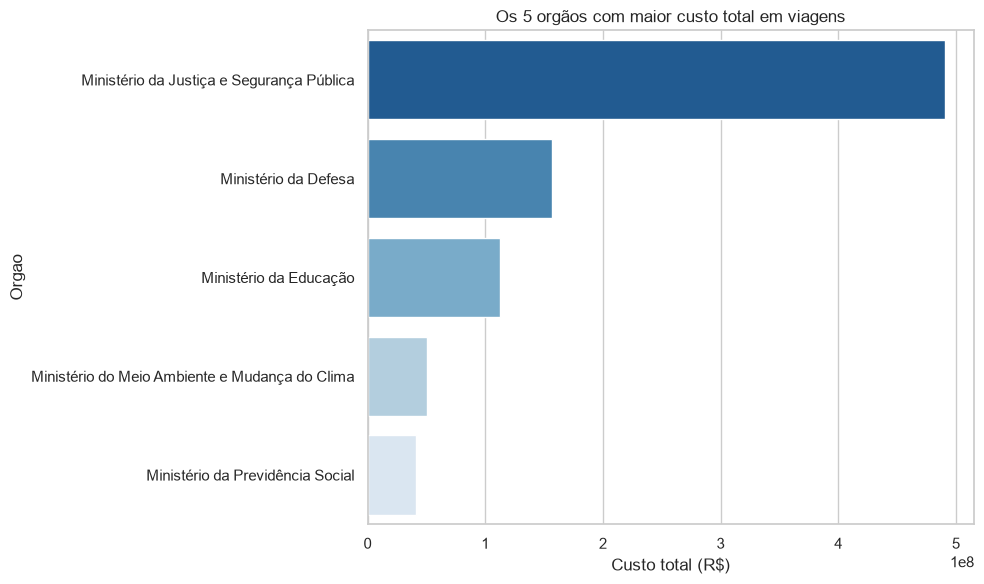

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_pergunta_1,
    y="nome_orgao_superior",
    x="custo_total",
    hue="nome_orgao_superior",
    palette="Blues_r",
    legend=False,
)
plt.title("Os 5 orgãos com maior custo total em viagens")
plt.xlabel("Custo total (R$)")
plt.ylabel("Orgao")
plt.tight_layout()
plt.show()

## Pergunta 2: Os 3 destinos com maior custo médio por viagem?

Calcula a média de `valor_total` das viagens, agrupado por `destinos`.

In [35]:
query_2 = """
    SELECT
        SPLIT_PART(destinos, ',', 1) AS destino_principal,
        AVG(valor_total) AS custo_medio,
        COUNT(*) AS qtd_viagens
    FROM silver_viagem
    WHERE destinos IS NOT NULL
    GROUP BY destino_principal
    HAVING COUNT(*) >= 5
    ORDER BY custo_medio DESC
    LIMIT 3;
"""

df_pergunta_2 = pd.read_sql(query_2, conexao)
df_pergunta_2

C:\Users\Luan\AppData\Local\Temp\ipykernel_27372\1414783679.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta_2 = pd.read_sql(query_2, conexao)


,destino_principal,custo_medio,qtd_viagens
0,Nova Maringá/MT,70621.264000,5
1,Cologne/Alemanha,51689.403333,12
2,Planalto/RS,47156.892941,17


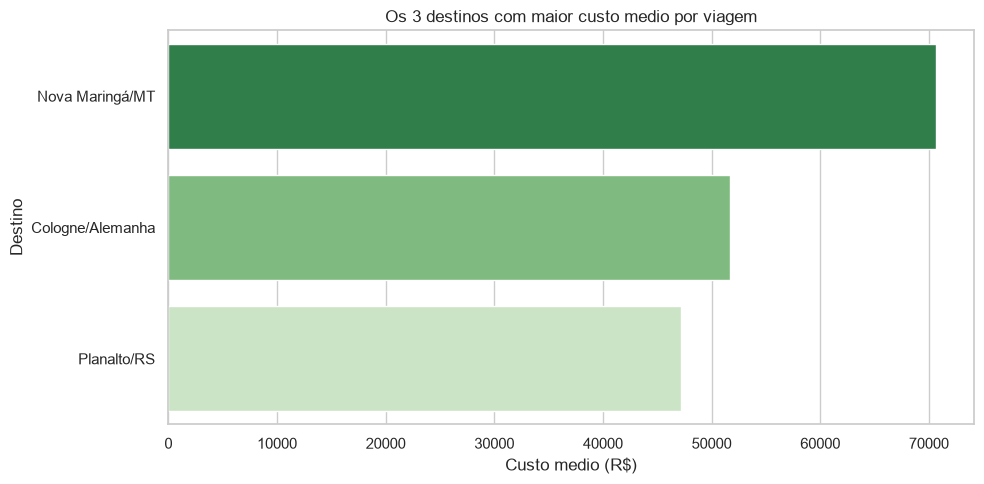

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_pergunta_2,
    y="destino_principal",
    x="custo_medio",
    hue="destino_principal",
    palette="Greens_r",
    legend=False,
)
plt.title("Os 3 destinos com maior custo medio por viagem")
plt.xlabel("Custo medio (R$)")
plt.ylabel("Destino")
plt.tight_layout()
plt.show()

## Pergunta 3: A viagem de maior duracao e seu custo total?

Identifica a viagem com o maior `duracao_dias`, trazendo também seu custo
total e compara com a duração média das viagens.

In [37]:
query_3 = """
    SELECT
        id_viagem, nome_viajante, destinos, motivo,
        duracao_dias, valor_total
    FROM silver_viagem
    WHERE duracao_dias IS NOT NULL
    ORDER BY duracao_dias DESC
    LIMIT 1;
"""

df_pergunta_3 = pd.read_sql(query_3, conexao)
df_pergunta_3

C:\Users\Luan\AppData\Local\Temp\ipykernel_27372\2602803456.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta_3 = pd.read_sql(query_3, conexao)


,id_viagem,nome_viajante,destinos,motivo,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Mogi Mirim/SP,"Convocar o servidor, para atuação presencial j...",383,0.0


C:\Users\Luan\AppData\Local\Temp\ipykernel_27372\4057498865.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  duracao_media = pd.read_sql(query_3_media, conexao)["duracao_media"][0]


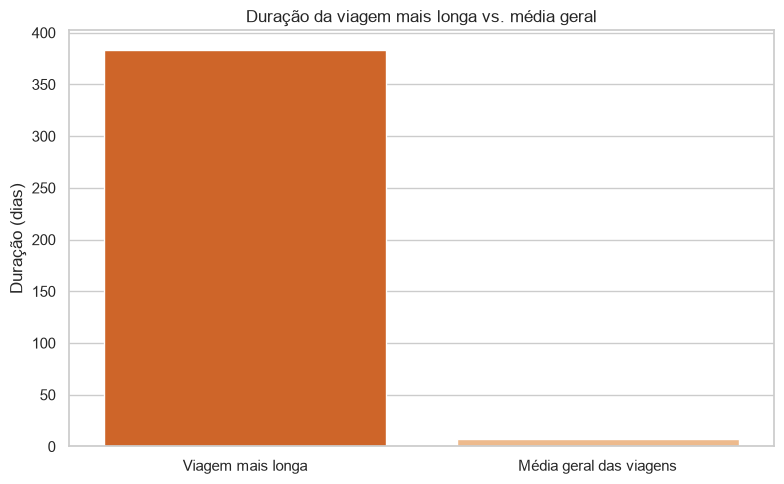

In [38]:
query_3_media = """
    SELECT AVG(duracao_dias) AS duracao_media
    FROM silver_viagem
    WHERE duracao_dias IS NOT NULL;
"""

duracao_media = pd.read_sql(query_3_media, conexao)["duracao_media"][0]
duracao_maxima = df_pergunta_3["duracao_dias"][0]

df_comparacao = pd.DataFrame({
    "tipo": ["Viagem mais longa", "Média geral das viagens"],
    "duracao_dias": [duracao_maxima, duracao_media],
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_comparacao,
    x="tipo",
    y="duracao_dias",
    hue="tipo",
    palette="Oranges_r",
    legend=False,
)
plt.title("Duração da viagem mais longa vs. média geral")
plt.xlabel("")
plt.ylabel("Duração (dias)")
plt.tight_layout()
plt.show()

## Camada Gold: criacao da tabela e da view agregada

Cria um resumo consolidado por orgao superior, juntando `silver_viagem`
com `silver_trecho` via JOIN, e agregando com GROUP BY: quantidade de
viagens, custo total, custo medio por viagem, e quantidade de trechos.

In [39]:
sql_criar_gold_tabela = """
    DROP TABLE IF EXISTS gold_resumo_orgao;

    CREATE TABLE gold_resumo_orgao AS
    SELECT
        v.nome_orgao_superior,
        COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
        SUM(v.valor_total) AS custo_total,
        AVG(v.valor_total) AS custo_medio_viagem,
        COUNT(t.id_trecho) AS qtd_trechos
    FROM silver_viagem v
    LEFT JOIN silver_trecho t ON v.id_viagem = t.id_viagem
    GROUP BY v.nome_orgao_superior;
"""

banco.executar(conexao, sql_criar_gold_tabela)
print("Tabela gold_resumo_orgao criada com sucesso.")

Tabela gold_resumo_orgao criada com sucesso.


In [40]:
sql_criar_gold_view = """
    DROP VIEW IF EXISTS gold_resumo_orgao_view;

    CREATE VIEW gold_resumo_orgao_view AS
    SELECT
        v.nome_orgao_superior,
        COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
        SUM(v.valor_total) AS custo_total,
        AVG(v.valor_total) AS custo_medio_viagem,
        COUNT(t.id_trecho) AS qtd_trechos
    FROM silver_viagem v
    LEFT JOIN silver_trecho t ON v.id_viagem = t.id_viagem
    GROUP BY v.nome_orgao_superior;
"""

banco.executar(conexao, sql_criar_gold_view)
print("View gold_resumo_orgao_view criada com sucesso.")

View gold_resumo_orgao_view criada com sucesso.


In [41]:
df_gold = pd.read_sql("SELECT * FROM gold_resumo_orgao ORDER BY custo_total DESC;", conexao)
df_gold

C:\Users\Luan\AppData\Local\Temp\ipykernel_27372\1553004574.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gold = pd.read_sql("SELECT * FROM gold_resumo_orgao ORDER BY custo_total DESC;", conexao)


,nome_orgao_superior,qtd_viagens,custo_total,custo_medio_viagem,qtd_trechos
0,Ministério da Justiça e Segurança Pública,75742,4.268235e+09,29243.901661,95096
1,Ministério da Defesa,61912,4.461255e+08,2756.566475,161823
2,Ministério da Educação,65295,2.903178e+08,1903.111618,152531
3,Ministério do Meio Ambiente e Mudança do Clima,19413,1.904911e+08,3256.703694,58363
4,Ministério da Previdência Social,8190,1.061688e+08,4942.450357,21477
5,Ministério da Saúde,8672,9.706322e+07,4607.358283,21061
6,Ministério dos Povos Indígenas,5101,8.097587e+07,5690.103947,14229
7,Ministério da Fazenda,11854,7.930358e+07,3122.679900,25109
8,Não informado,14768,7.867542e+07,1925.864630,40851
9,Ministério do Desenvolvimento Agrário e Agricu...,8581,6.381070e+07,2770.764290,23030


## Pergunta 4: Qual o tipo de pagamento com maior valor médio?

Calcula o valor médio de `silver_pagamento`, agrupado por `tipo_pagamento`.

In [42]:
query_4 = """
    SELECT
        tipo_pagamento,
        AVG(valor) AS valor_medio,
        COUNT(*) AS qtd_pagamentos
    FROM silver_pagamento
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC;
"""

df_pergunta_4 = pd.read_sql(query_4, conexao)
df_pergunta_4

C:\Users\Luan\AppData\Local\Temp\ipykernel_27372\4264577479.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta_4 = pd.read_sql(query_4, conexao)


,tipo_pagamento,valor_medio,qtd_pagamentos
0,DIÁRIAS,2078.280299,401463
1,PASSAGEM,1878.344393,188985
2,Serviço correlato: seguro,447.514653,4894
3,RESTITUIÇÃO,245.702610,11574


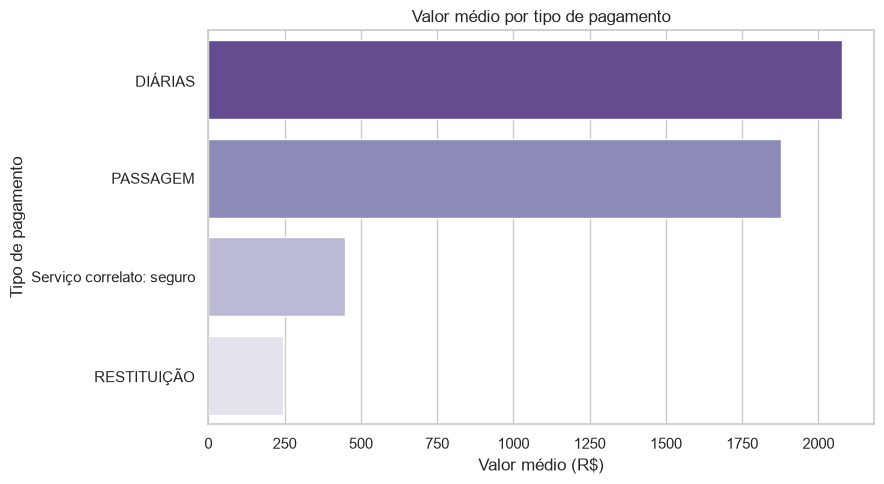

In [43]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_pergunta_4,
    y="tipo_pagamento",
    x="valor_medio",
    hue="tipo_pagamento",
    palette="Purples_r",
    legend=False,
)
plt.title("Valor médio por tipo de pagamento")
plt.xlabel("Valor médio (R$)")
plt.ylabel("Tipo de pagamento")
plt.tight_layout()
plt.show()

## Pergunta 5: Qual o meio de transporte mais usado nos trechos?

Conta a quantidade de trechos por `meio_transporte`, em `silver_trecho`.

In [44]:
query_5 = """
    SELECT
        meio_transporte,
        COUNT(*) AS qtd_trechos
    FROM silver_trecho
    WHERE meio_transporte IS NOT NULL
    GROUP BY meio_transporte
    ORDER BY qtd_trechos DESC;
"""

df_pergunta_5 = pd.read_sql(query_5, conexao)
df_pergunta_5

C:\Users\Luan\AppData\Local\Temp\ipykernel_27372\3777540723.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta_5 = pd.read_sql(query_5, conexao)


,meio_transporte,qtd_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


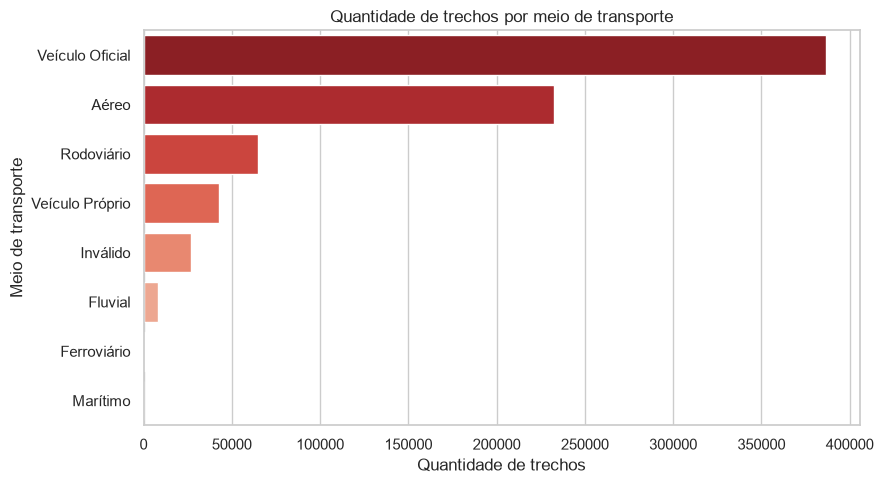

In [45]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_pergunta_5,
    y="meio_transporte",
    x="qtd_trechos",
    hue="meio_transporte",
    palette="Reds_r",
    legend=False,
)
plt.title("Quantidade de trechos por meio de transporte")
plt.xlabel("Quantidade de trechos")
plt.ylabel("Meio de transporte")
plt.tight_layout()
plt.show()

## Pergunta 6: Qual UF de destino aparece em mais trechos?

Conta a quantidade de trechos por `destino_uf`, em `silver_trecho`,
trazendo o top 10.

In [46]:
query_6 = """
    SELECT
        destino_uf,
        COUNT(*) AS qtd_trechos
    FROM silver_trecho
    WHERE destino_uf IS NOT NULL
    GROUP BY destino_uf
    ORDER BY qtd_trechos DESC
    LIMIT 10;
"""

df_pergunta_6 = pd.read_sql(query_6, conexao)
df_pergunta_6

C:\Users\Luan\AppData\Local\Temp\ipykernel_27372\111590621.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta_6 = pd.read_sql(query_6, conexao)


,destino_uf,qtd_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


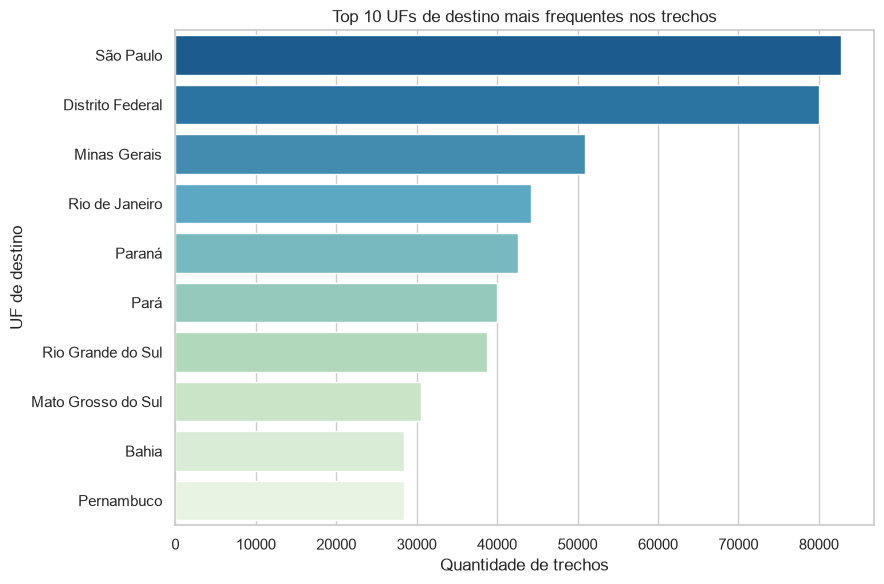

In [47]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_pergunta_6,
    y="destino_uf",
    x="qtd_trechos",
    hue="destino_uf",
    palette="GnBu_r",
    legend=False,
)
plt.title("Top 10 UFs de destino mais frequentes nos trechos")
plt.xlabel("Quantidade de trechos")
plt.ylabel("UF de destino")
plt.tight_layout()
plt.show()

## Pergunta 7: Qual orgao pagou mais no total?

In [48]:
query_7 = """
    SELECT
        nome_orgao_pagador,
        SUM(valor) AS total_pago,
        COUNT(*) AS qtd_pagamentos
    FROM silver_pagamento
    WHERE nome_orgao_pagador IS NOT NULL
    GROUP BY nome_orgao_pagador
    ORDER BY total_pago DESC
    LIMIT 5;
"""

df_pergunta_7 = pd.read_sql(query_7, conexao)
df_pergunta_7

C:\Users\Luan\AppData\Local\Temp\ipykernel_27372\4222611262.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta_7 = pd.read_sql(query_7, conexao)


,nome_orgao_pagador,total_pago,qtd_pagamentos
0,Fundo Nacional de Segurança Pública,2.784810e+08,79816
1,Sigiloso,2.004848e+08,93141
2,Comando da Aeronáutica,8.176914e+07,46193
3,Instituto Nacional do Seguro Social,3.742760e+07,18324
4,Comando do Exército,3.687264e+07,22837


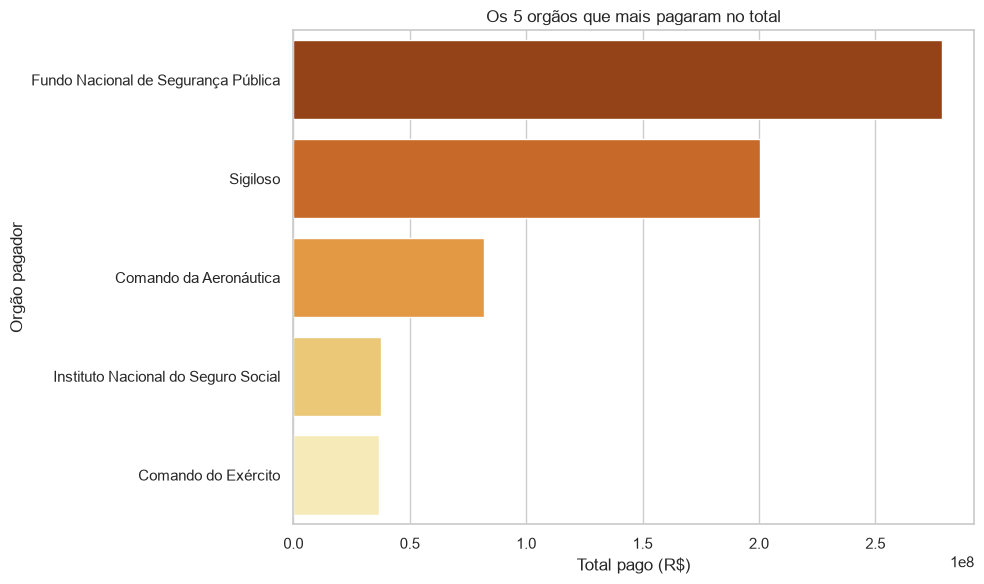

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_pergunta_7,
    y="nome_orgao_pagador",
    x="total_pago",
    hue="nome_orgao_pagador",
    palette="YlOrBr_r",
    legend=False,
)
plt.title("Os 5 orgãos que mais pagaram no total")
plt.xlabel("Total pago (R$)")
plt.ylabel("Orgão pagador")
plt.tight_layout()
plt.show()